In [ ]:
import pandas as pd

df = pd.read_csv('/content/q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


1. Data Preparation

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled[:5]

array([[-0.72521859, -0.17615043,  0.11016555, -0.26501121, -0.0899507 ,
         0.55095233],
       [-1.48846049, -1.04682639,  0.48615719, -0.9804657 , -0.83517593,
        -0.68068477],
       [ 0.17679458,  0.2673371 , -0.45382191, -0.23685064, -0.67404615,
        -0.27013907],
       [-0.72521859, -1.01230889,  0.29816137, -0.82778261, -0.99630571,
        -1.09123047],
       [-1.48846049, -1.03448783,  1.42613628, -1.00598621, -0.65390493,
        -1.50177617]])

All numerical features were scaled using StandardScaler to bring them to a common scale.
This step is important because K-Means clustering is based on distance calculations, and features with larger values (like annual_spend) can dominate the clustering process if data is not scaled.
Scaling ensures that all features contribute equally to the clustering.

2. Choosing K — Elbow Method

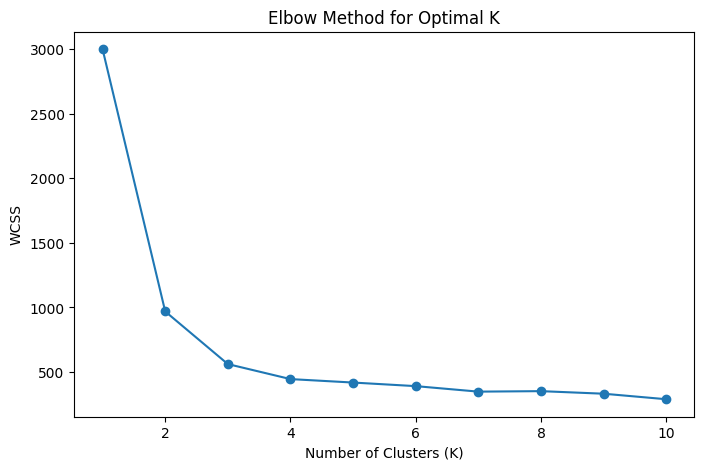

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

The Elbow Method was used to determine the optimal number of clusters by plotting WCSS against different values of K.
The graph shows a sharp decrease in WCSS up to K = 3, after which the decrease becomes more gradual.
This indicates that adding more clusters beyond K = 3 does not significantly improve clustering performance.
Therefore, the optimal number of clusters is chosen as K = 3.

3. K-Means Clustering

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [ ]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=df.drop('cluster', axis=1).columns
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


The K-Means clustering algorithm was applied with K = 3 to segment customers into distinct groups based on their behavior.

A new column named 'cluster' was added to the dataset, assigning each customer to a specific cluster. The cluster centroids were computed to understand the average characteristics of each group.

- Cluster 0: Represents customers with lower spending, fewer visits, and lower engagement across categories.
- Cluster 1: Represents high-value customers with higher annual spending, frequent visits, larger basket sizes, and purchases across multiple categories.
- Cluster 2: Represents customers with moderate behavior, showing average spending and visit frequency.

These clusters help in identifying different customer segments, enabling businesses to design targeted marketing strategies and improve customer engagement.

4. Dimensionality Reduction with PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca.explained_variance_ratio_

array([0.83560354, 0.05568764])

In [ ]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.drop('cluster', axis=1).columns,
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PCA was applied to reduce the dataset into two principal components while preserving most of the information.

The explained variance ratio shows that PC1 captures approximately 83.5% of the variance, while PC2 captures around 5.6%. This means that most of the important information in the dataset is retained in these two components.

Based on the feature loadings:
- PC1 is mainly influenced by features such as age, annual_spend, basket_size, and number of categories purchased, representing overall customer value and purchasing behavior.
- PC2 is strongly influenced by days_since_last_visit, indicating customer recency and engagement patterns.

Thus, PCA helps in simplifying the dataset while retaining key behavioral patterns of customers.

5. Cluster Visualisation

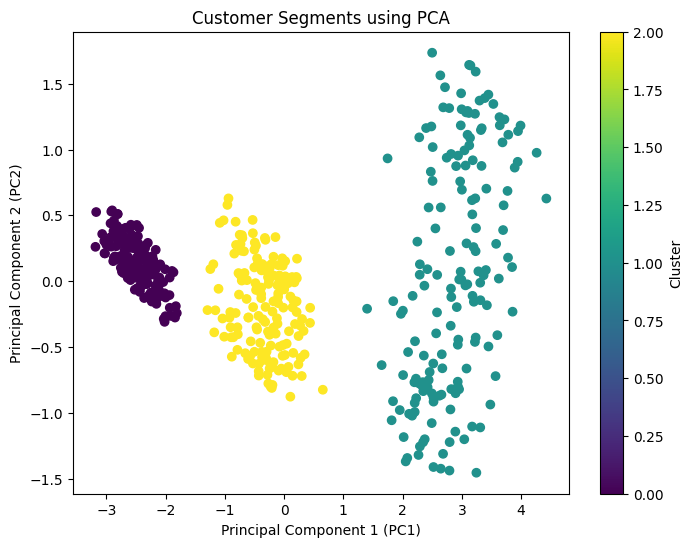

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df['cluster'],
    cmap='viridis'
)

plt.title('Customer Segments using PCA')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')

plt.colorbar(label='Cluster')
plt.show()

The scatter plot visualizes customer segments using the two principal components obtained from PCA.

Each point represents a customer, and the colors indicate the cluster assigned by the K-Means algorithm. The plot shows a clear separation between the three clusters, indicating that the clustering model has effectively grouped customers based on their behavior.

Cluster separation along PC1 reflects differences in overall customer value and purchasing behavior, while variation along PC2 represents differences in recency and engagement.

This visualization helps in understanding customer segments in a simplified 2D space and can be used for targeted marketing and business decision-making.